In [126]:
import pandas as pd
import numpy as np
import calendar
import re

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec

def seconds_to_mmsscc(x, pos):
    m = int(x // 60)
    s = int(x % 60)
    c = int(round((x - int(x)) * 100))
    return f"{m:02d}:{s:02d}" #:{c:02d}"

## Data Cleaning

In [127]:
# Load dataset
df = pd.read_csv('beer_mile_data.csv').iloc[:, 1:]
df['date'] = pd.to_datetime(df['date'])
df.dropna(inplace=True)
df.head()

,Time,Nationality,Division,Official,Beer,Container,date,lat,lon,temperature,humidity,precipitation
0,4:27.10,Canada,Men - All Ages,Official,Flying Monkeys,Bottle,2025-07-26,38.707009,-9.135641,28.1,35.0,0.0
1,4:47.17,Canada,Men - All Ages,Official,Amsterdam Blonde,Bottle,2015-12-02,30.264979,-97.746598,10.7,74.0,0.0
2,4:47.39,United States,Men - All Ages,Official,Budweiser,Bottle,2016-08-01,51.507408,-0.127699,15.2,79.0,12.7
3,4:47.72,United States,Men - All Ages,Official,Bud Light Platinum,Bottle,2016-07-17,34.447966,-119.242981,21.4,69.0,0.0
4,4:48.62,Canada,Men - All Ages,Official,Bud Light Platinum,Bottle,2015-12-02,30.264979,-97.746598,10.7,74.0,0.0


In [128]:
df['Division'] = df['Division'].apply(lambda x: 'Male' if 'Men' in x else 'Female')
df.rename(columns={'Division':'Gender'}, inplace=True)

df = df[df.Container.isin(['Bottle','Can'])]

In [129]:
# Convert Time column to seconds
df['Time'] = (
    df['Time'].apply(lambda x: x.replace('.',':'))
    .str.split(':')
    .apply(lambda x: int(x[0]) * 60 + int(x[1]) + int(x[2]) / 100))

# Add season and month
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'
    
df['Season'] = df['date'].dt.month.apply(month_to_season)
df['Month'] = df.date.dt.month_name()

df.head()

,Time,Nationality,Gender,Official,Beer,Container,date,lat,lon,temperature,humidity,precipitation,Season,Month
0,267.10,Canada,Male,Official,Flying Monkeys,Bottle,2025-07-26,38.707009,-9.135641,28.1,35.0,0.0,Summer,July
1,287.17,Canada,Male,Official,Amsterdam Blonde,Bottle,2015-12-02,30.264979,-97.746598,10.7,74.0,0.0,Winter,December
2,287.39,United States,Male,Official,Budweiser,Bottle,2016-08-01,51.507408,-0.127699,15.2,79.0,12.7,Summer,August
3,287.72,United States,Male,Official,Bud Light Platinum,Bottle,2016-07-17,34.447966,-119.242981,21.4,69.0,0.0,Summer,July
4,288.62,Canada,Male,Official,Bud Light Platinum,Bottle,2015-12-02,30.264979,-97.746598,10.7,74.0,0.0,Winter,December


C:\Users\lucam\AppData\Local\Temp\ipykernel_23456\845367893.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(events_per_bin['period'], rotation=45, ha='right')


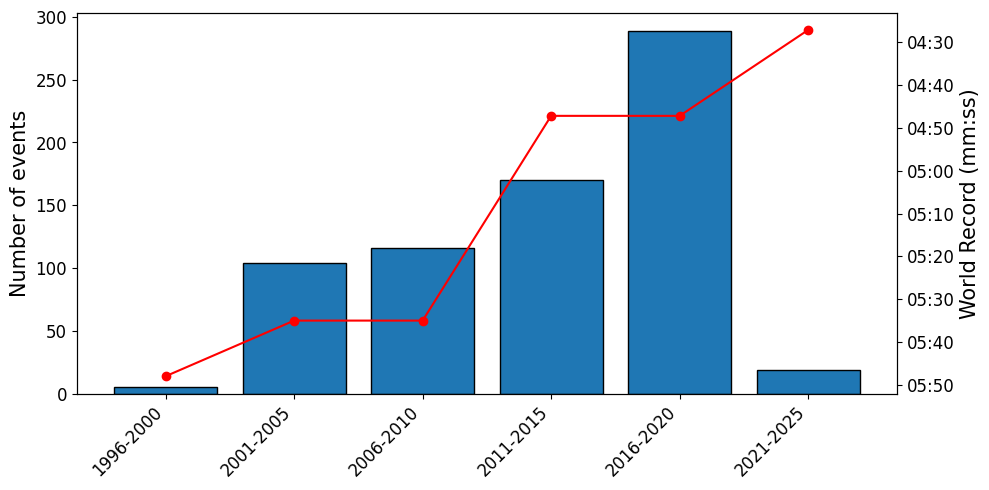

In [130]:
# get unique events
events = df.drop_duplicates(subset=['date', 'lon', 'lat']).copy()
events = events[events.date.dt.year >= 1996]

# create 5-year bins
events['year'] = events['date'].dt.year
events['year_bin'] = ((events['year'] - 1) // 5) * 5 + 1

events_per_bin = (
    events
    .groupby('year_bin')
    .size()
    .reset_index(name='n_events')
)

# nicely formatted labels
events_per_bin['period'] = events_per_bin['year_bin'].astype(str) + '-' + (events_per_bin['year_bin'] + 4).astype(str)

record_per_bin = events.groupby('year_bin')['Time'].min().sort_index().cummin().reset_index(name='record_time')
record_per_bin['period'] = record_per_bin['year_bin'].astype(str) + '-' + (record_per_bin['year_bin'] + 4).astype(str)

# bar plot
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(events_per_bin['period'], events_per_bin['n_events'], color='tab:blue', edgecolor='black')
ax.set_xticklabels(events_per_bin['period'], rotation=45, ha='right')
ax.set_ylabel("Number of events", fontsize=15)

ax2 = ax.twinx()
ax2.plot(record_per_bin['period'], record_per_bin['record_time'], color='red', marker='o', label='Best Time')
ax2.set_ylabel('World Record (mm:ss)', fontsize=15)
ax2.yaxis.set_major_formatter(FuncFormatter(seconds_to_mmsscc))
ax2.invert_yaxis()
ax.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()

In [131]:
# format the Beer column
df['Beer'] = df['Beer'].apply(lambda x: str(x).lower())
df['Beer'] = df['Beer'].replace({'Molson Canadian': 'Molson'})

beers = ['budweiser', 'slingshot','bud light', 'pabst', 'miller', 'coors', 'heineken', 'blue moon','lager','molson','stella','brooklyn','milwaukee']
#beers = ['bud light','budweiser','pabst','miller','coors','heineken','blue moon','stella','brooklyn','molson','lager']

dfs_by_beer = []
for b in beers:
    pattern = rf'\b{re.escape(b)}\b'  # matches whole word only
    df_temp = df[df['Beer'].str.contains(pattern, regex=True)].copy()
    df_temp['Beer'] = b
    dfs_by_beer.append(df_temp)

df = pd.concat(dfs_by_beer).reset_index(drop=True)

# add ABV to each beer type
abv_map = {
    'budweiser': 5.0,
    'bud light': 4.2,
    'pabst': 4.7,
    'miller': 4.6,
    'coors': 5.0,
    'heineken': 5.0,
    'blue moon': 5.4,
    'lager': 5.0,
    'molson': 5.0,
    'stella': 5.0,
    'brooklyn': 5.0,
    'slingshot': 5.0,
    'canadian': 5.0
}

df['abv'] = df['Beer'].map(abv_map)

df.head()

,Time,Nationality,Gender,Official,Beer,Container,date,lat,lon,temperature,humidity,precipitation,Season,Month,abv
0,287.39,United States,Male,Official,budweiser,Bottle,2016-08-01,51.507408,-0.127699,15.2,79.0,12.7,Summer,August,5.0
1,294.50,United States,Male,Official,budweiser,Bottle,2016-07-09,37.780077,-122.420162,16.4,79.0,0.0,Summer,July,5.0
2,297.00,United States,Male,Official,budweiser,Can,2014-05-27,37.780077,-122.420162,15.8,60.0,0.0,Spring,May,5.0
3,305.20,United States,Male,Official,budweiser,Bottle,2015-08-09,44.826255,-93.303856,22.4,82.0,2.1,Summer,August,5.0
4,316.00,United States,Male,Official,budweiser,Bottle,2019-03-17,37.780077,-122.420162,13.3,81.0,0.0,Spring,March,5.0


In [132]:
# check no NaNs
print(f'There are {df.isna().sum().sum()} NaN values.')

There are 79 NaN values.


## Exploratory Data Analysis

In [133]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

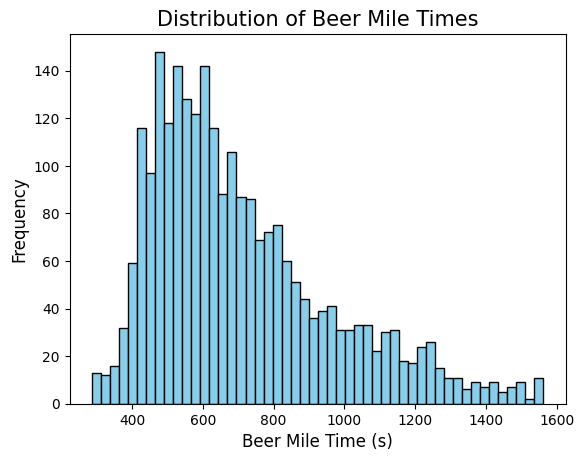

In [134]:
plt.hist((df.Time), bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Beer Mile Time (s)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Beer Mile Times', fontsize=15)

plt.show()

In [135]:
import geopandas as gpd
from shapely.geometry import Point

world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

df_bubble = df.groupby(['lat', 'lon']).size().reset_index(name='count')

gdf = gpd.GeoDataFrame(df_bubble, geometry=[Point(xy) for xy in zip(df_bubble['lon'], df_bubble['lat'])], crs="EPSG:4326")

C:\Users\lucam\AppData\Local\Temp\ipykernel_23456\1494813179.py:4: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


In [136]:
gdf_with_countries = gpd.sjoin(gdf, world[['geometry', 'name', 'iso_a3']], how='left', predicate='within')

obs_per_country = gdf_with_countries.groupby(['name', 'iso_a3']).agg({'count': 'sum'}).reset_index().rename(columns={'name': 'country_name', 'iso_a3': 'country_code'})

obs_per_country['percentage'] = obs_per_country['count'] / obs_per_country['count'].sum()

print('Top 5 countries hosting the event')
print(obs_per_country.sort_values(by='percentage', ascending=False).iloc[:5,[0,-1]])

Top 5 countries hosting the event
                country_name  percentage
24  United States of America    0.649144
2                     Canada    0.140179
11                 Indonesia    0.029747
23            United Kingdom    0.025672
3                    Czechia    0.024857


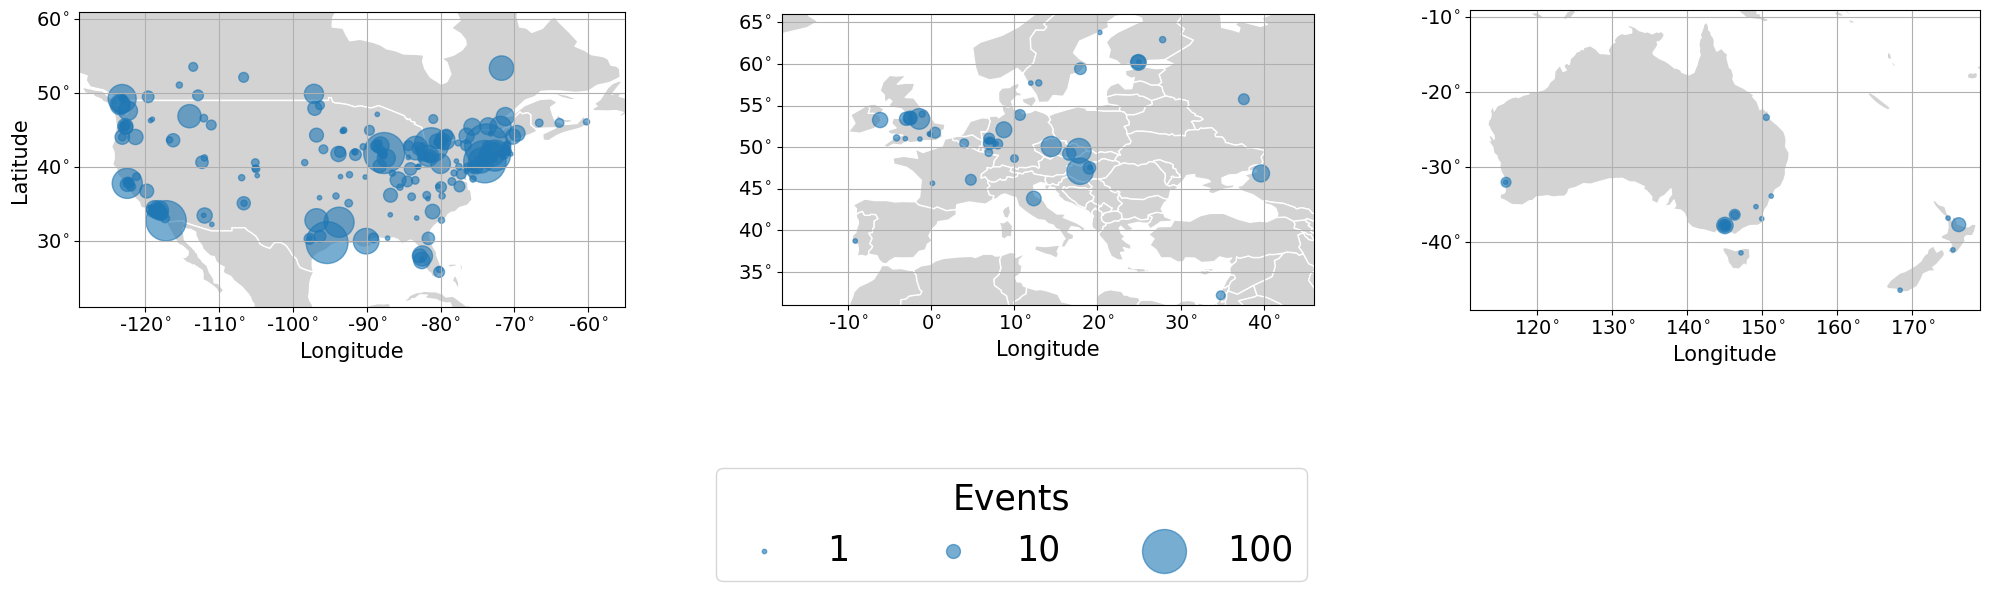

In [137]:
def degree_formatter(x, pos):
    return f"{x:.0f}" + r'$^{\circ}$'

# Compute x-axis ranges to scale widths
x0_range = -55 - (-130)   # left map (Americas)
x1_range = 55 - (-18)     # right map (Europe/Africa)
x2_range = 180 - (110)    # Australia map

# Create figure with proportional widths
fig = plt.figure(figsize=(20, 10))
gs = GridSpec(1, 3, width_ratios=[x0_range, x1_range, x2_range], figure=fig)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

# Plot base maps
world.plot(ax=ax0, color='lightgray', edgecolor='white')
world.plot(ax=ax1, color='lightgray', edgecolor='white')
world.plot(ax=ax2, color='lightgray', edgecolor='white')

# Set axis limits
ax0.set_xlim(-129, -55)   # Americas
ax0.set_ylim(21, 61)
ax1.set_xlim(-18, 46)     # Europe/Africa
ax1.set_ylim(31, 66)
ax2.set_xlim(111, 179)    # Australia
ax2.set_ylim(-49, -9)   

# Scatter plots
gdf.plot(ax=ax0, kind='scatter', x='lon', y='lat', s=gdf['count'] * 10, color='tab:blue', alpha=0.6)
gdf.plot(ax=ax1, kind='scatter', x='lon', y='lat', s=gdf['count'] * 10, color='tab:blue', alpha=0.6)
gdf.plot(ax=ax2, kind='scatter', x='lon', y='lat', s=gdf['count'] * 10, color='tab:blue', alpha=0.6)

# Set labels
for a in [ax0, ax1, ax2]:
    a.set_xlabel('Longitude', fontsize=15)
    a.set_ylabel('', fontsize=15)
    a.xaxis.set_major_formatter(FuncFormatter(degree_formatter))
    a.yaxis.set_major_formatter(FuncFormatter(degree_formatter))
    a.tick_params(axis='both', labelsize=14)
    a.grid(True)
    a.set_aspect('equal', adjustable='box')  # ensure same scale for x and y

ax0.set_ylabel('Latitude', fontsize=15)

# Legend for example counts
example_counts = [1, 10, 100]
example_sizes = [c * 10 for c in example_counts]
for size, count in zip(example_sizes, example_counts):
    ax1.scatter([], [], s=size, color='tab:blue', alpha=0.6, label=f'{count}')

ax1.legend(title='Events', ncol=3, scatterpoints=1, frameon=True, fontsize=25, title_fontsize=25, bbox_to_anchor=(1.02, -0.5))
plt.tight_layout()
plt.show()

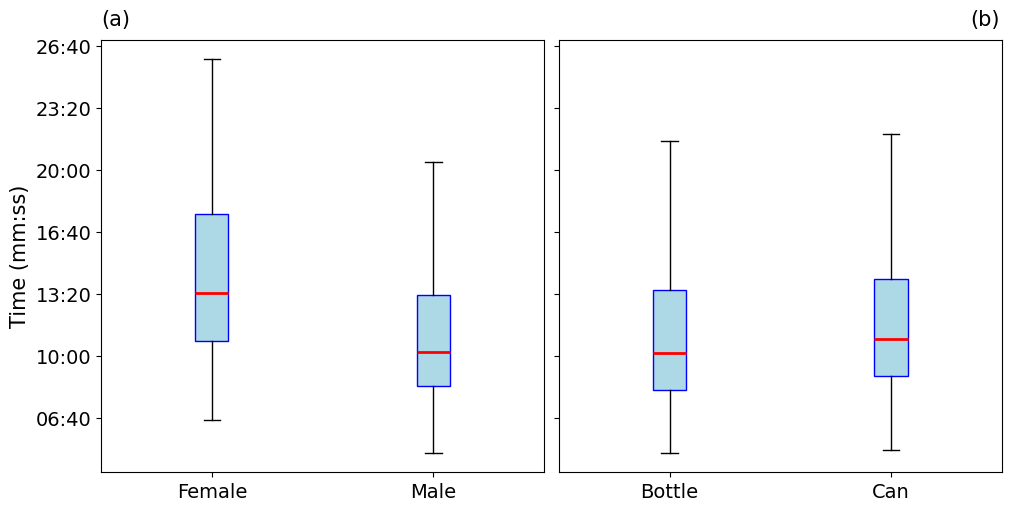

In [138]:
cols = ['Gender','Container']

fig, ax = plt.subplots(1, 2, figsize=(10,5), sharey=True, layout='constrained')

for i, c in enumerate(cols):
    groups = df.groupby(c)['Time']

    ax[i].boxplot([groups.get_group(g) for g in groups.groups],
                tick_labels=groups.groups.keys(),
                patch_artist=True,
                showfliers=False,
                boxprops=dict(facecolor="lightblue", color="blue"),
                medianprops=dict(color="red", linewidth=2))
    
    ax[i].yaxis.set_major_formatter(FuncFormatter(seconds_to_mmsscc))

ax[0].set_ylabel('Time (mm:ss)', fontsize=15)
ax[0].tick_params(axis='both', labelsize=14)
ax[1].tick_params(axis='both', labelsize=14)

ax[0].annotate("(a)", xy=(0., 1.07), xycoords="axes fraction", fontsize=15, va="top")
ax[1].annotate("(b)", xy=(0.93, 1.07), xycoords="axes fraction", fontsize=15, va="top");

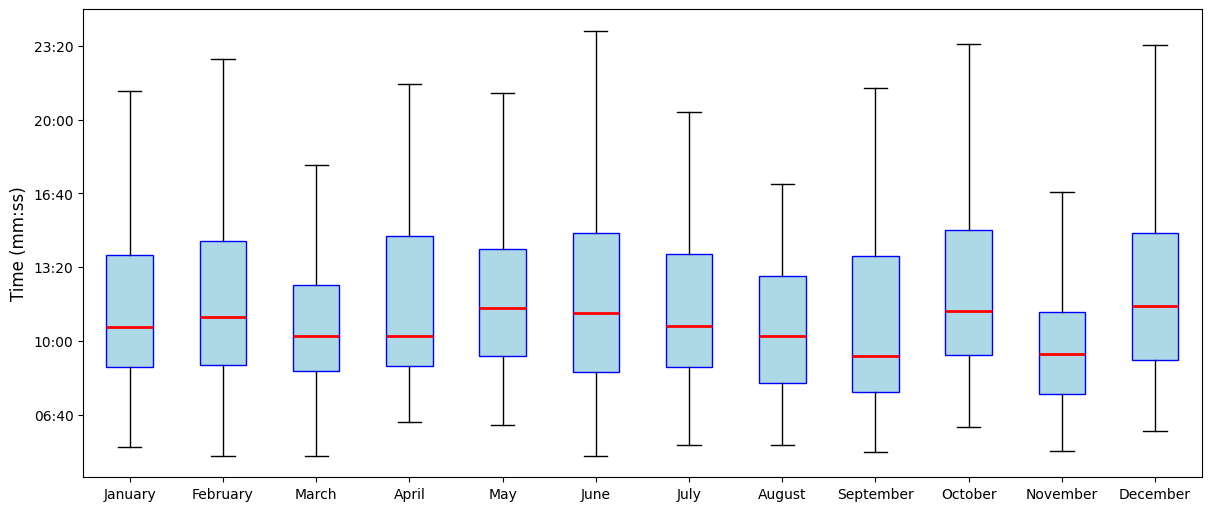

In [139]:
month_order = list(calendar.month_name[1:])

fig, ax = plt.subplots(1, 1, figsize=(12,5), sharey=True, layout='constrained')

groups = df.groupby('Month')['Time']
ordered_months = [m for m in month_order if m in groups.groups]

ax.boxplot([groups.get_group(g) for g in groups.groups],
            tick_labels=ordered_months,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(facecolor="lightblue", color="blue"),
            medianprops=dict(color="red", linewidth=2))

ax.yaxis.set_major_formatter(FuncFormatter(seconds_to_mmsscc))

ax.set_ylabel('Time (mm:ss)', fontsize=12);

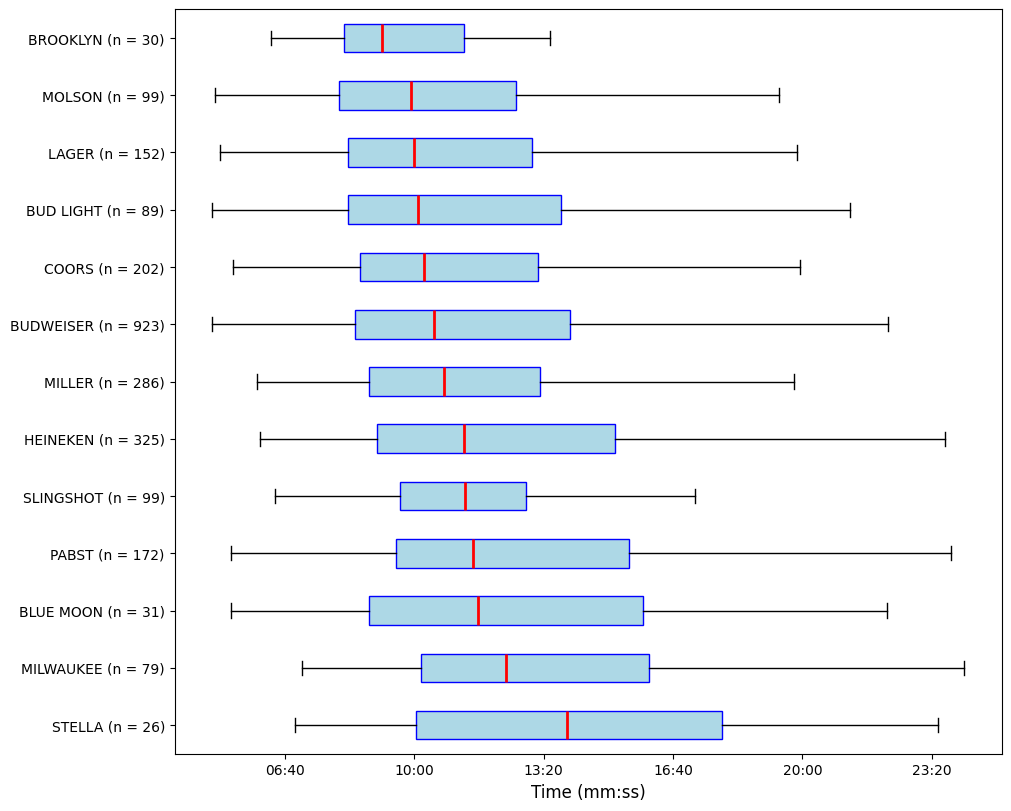

In [140]:
fig, ax = plt.subplots(1, 1, figsize=(10,8), sharey=True, layout='constrained')

groups = df.groupby('Beer')['Time']

medians = {g: groups.get_group(g).median() for g in groups.groups}

sorted_beers = sorted(medians, key=medians.get)[::-1]

data_sorted = [groups.get_group(b) for b in sorted_beers]

labels_with_counts = [f"{b.upper()} (n = {len(groups.get_group(b))})" for b in sorted_beers]

ax.boxplot(data_sorted,
            vert=False,
            tick_labels=labels_with_counts,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(facecolor="lightblue", color="blue"),
            medianprops=dict(color="red", linewidth=2))

ax.xaxis.set_major_formatter(FuncFormatter(seconds_to_mmsscc))

ax.set_xlabel('Time (mm:ss)', fontsize=12);

In [141]:
df.to_csv('beer_mile_data_CLEAN.csv')